In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb
import joblib
import warnings
import json
from datetime import datetime
import os
 
warnings.filterwarnings('ignore')
 
# Set random seed for reproducibility
np.random.seed(42)
 
# Create directories for models and outputs
os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('results', exist_ok=True)
 
print(" All imports successful!")
print(f" Session started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
 

 All imports successful!
 Session started: 2026-07-03 23:55:24


In [3]:
# Load UCI Chronic Kidney Disease dataset
uci_data = pd.read_csv(r"C:\Users\DELL\nephrocare\data\processed\uci_ckd.csv")
 
print("=" * 80)
print("UCI CHRONIC KIDNEY DISEASE DATASET")
print("=" * 80)
print(f"Shape: {uci_data.shape}")
print(f"\nFirst few rows:")
print(uci_data.head())
print(f"\nColumn names:")
print(uci_data.columns.tolist())
print(f"\nData types:")
print(uci_data.dtypes)
print(f"\nMissing values:")
print(uci_data.isnull().sum())
print(f"\nTarget variable distribution:")
print(uci_data['ckd_label'].value_counts())

UCI CHRONIC KIDNEY DISEASE DATASET
Shape: (400, 26)

First few rows:
    age  blood_pressure  specific_gravity  albumin  sugar red_blood_cells  \
0  48.0            80.0             1.020      1.0    0.0             NaN   
1   7.0            50.0             1.020      4.0    0.0             NaN   
2  62.0            80.0             1.010      2.0    3.0          normal   
3  48.0            70.0             1.005      4.0    0.0          normal   
4  51.0            80.0             1.010      2.0    0.0          normal   

   pus_cell pus_cell_clumps    bacteria  blood_glucose_random  ...  \
0    normal      notpresent  notpresent                 121.0  ...   
1    normal      notpresent  notpresent                   NaN  ...   
2    normal      notpresent  notpresent                 423.0  ...   
3  abnormal         present  notpresent                 117.0  ...   
4    normal      notpresent  notpresent                 106.0  ...   

   white_blood_cell_count  red_blood_cell_count

In [4]:
#  UCI DATA PREPROCESSING (FIXED)

df_uci = uci_data.copy()

# Remove nearly empty rows
df_uci = df_uci.dropna(thresh=10)

print(f"Rows after removing completely empty rows: {len(df_uci)}")

selected_features = [
    'age',
    'blood_pressure',
    'blood_glucose_random',
    'blood_urea',
    'serum_creatinine',
    'sodium',
    'potassium',
    'hemoglobin',
    'hypertension',
    'diabetes_mellitus'
]

target_col = 'ckd_label'

df_uci_clean = df_uci[selected_features + [target_col]].copy()

# Fill numerical missing values
num_cols = [
    'age',
    'blood_pressure',
    'blood_glucose_random',
    'blood_urea',
    'serum_creatinine',
    'sodium',
    'potassium',
    'hemoglobin'
]

for col in num_cols:
    df_uci_clean[col] = df_uci_clean[col].fillna(
        df_uci_clean[col].median()
    )

# Fill categorical missing values
for col in ['hypertension', 'diabetes_mellitus']:
    df_uci_clean[col] = df_uci_clean[col].fillna(
        df_uci_clean[col].mode()[0]
    )

print(f"Shape after preprocessing: {df_uci_clean.shape}")

print("\nTarget distribution:")
print(df_uci_clean[target_col].value_counts())

print(f"\nCKD Prevalence: {df_uci_clean[target_col].mean()*100:.2f}%")

Rows after removing completely empty rows: 400
Shape after preprocessing: (400, 11)

Target distribution:
ckd_label
1    250
0    150
Name: count, dtype: int64

CKD Prevalence: 62.50%


In [5]:
# Store encoders so we can use them later during prediction
encoders_uci = {}

# Convert yes/no values into 0 and 1
for col in ['hypertension', 'diabetes_mellitus']:

    le = LabelEncoder()

    df_uci_clean[col] = le.fit_transform(
        df_uci_clean[col].astype(str)
    )

    encoders_uci[col] = le

    print(f"\n{col} encoding:")
    print(dict(zip(
        le.classes_,
        le.transform(le.classes_)
    )))

print("\nDataset Shape After Encoding:")
print(df_uci_clean.shape)

print("\nFirst 5 Rows:")
print(df_uci_clean.head())


hypertension encoding:
{'no': np.int64(0), 'yes': np.int64(1)}

diabetes_mellitus encoding:
{'no': np.int64(0), 'yes': np.int64(1)}

Dataset Shape After Encoding:
(400, 11)

First 5 Rows:
    age  blood_pressure  blood_glucose_random  blood_urea  serum_creatinine  \
0  48.0            80.0                 121.0        36.0               1.2   
1   7.0            50.0                 121.0        18.0               0.8   
2  62.0            80.0                 423.0        53.0               1.8   
3  48.0            70.0                 117.0        56.0               3.8   
4  51.0            80.0                 106.0        26.0               1.4   

   sodium  potassium  hemoglobin  hypertension  diabetes_mellitus  ckd_label  
0   138.0        4.4        15.4             1                  1          1  
1   138.0        4.4        11.3             0                  0          1  
2   138.0        4.4         9.6             0                  1          1  
3   111.0        2.5

In [6]:
# Separate features (X) and target (y)
X_uci = df_uci_clean[selected_features]
y_uci = df_uci_clean[target_col]

# Scale numerical values so all features are on similar range
scaler_uci = StandardScaler()

X_uci_scaled = scaler_uci.fit_transform(X_uci)

# Convert scaled array back to dataframe
X_uci_scaled = pd.DataFrame(
    X_uci_scaled,
    columns=selected_features
)

print("Feature Scaling Completed")

# Split dataset into 80% training and 20% testing
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci_scaled,
    y_uci,
    test_size=0.20,
    random_state=42,
    stratify=y_uci
)

print("\nTrain-Test Split Completed")
print(f"Training Set Shape: {X_train_uci.shape}")
print(f"Testing Set Shape: {X_test_uci.shape}")

print("\nTraining Target Distribution:")
print(y_train_uci.value_counts())

print("\nTesting Target Distribution:")
print(y_test_uci.value_counts())

Feature Scaling Completed

Train-Test Split Completed
Training Set Shape: (320, 10)
Testing Set Shape: (80, 10)

Training Target Distribution:
ckd_label
1    200
0    120
Name: count, dtype: int64

Testing Target Distribution:
ckd_label
1    50
0    30
Name: count, dtype: int64


In [7]:
# Create XGBoost classifier

xgb_risk_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

print("Training CKD Risk Prediction Model...")

xgb_risk_model.fit(
    X_train_uci,
    y_train_uci
)

print("Model Training Completed")

Training CKD Risk Prediction Model...
Model Training Completed


In [8]:
# Predict CKD status
y_pred_risk = xgb_risk_model.predict(X_test_uci)

# Predict probability scores
y_pred_proba_risk = xgb_risk_model.predict_proba(X_test_uci)[:, 1]

# Calculate evaluation metrics
accuracy_risk = accuracy_score(y_test_uci, y_pred_risk)
precision_risk = precision_score(y_test_uci, y_pred_risk)
recall_risk = recall_score(y_test_uci, y_pred_risk)
f1_risk = f1_score(y_test_uci, y_pred_risk)
roc_auc_risk = roc_auc_score(y_test_uci, y_pred_proba_risk)

print("="*60)
print("CKD RISK MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy_risk:.4f}")
print(f"Precision : {precision_risk:.4f}")
print(f"Recall    : {recall_risk:.4f}")
print(f"F1 Score  : {f1_risk:.4f}")
print(f"ROC AUC   : {roc_auc_risk:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_uci, y_pred_risk))

CKD RISK MODEL PERFORMANCE
Accuracy  : 0.9750
Precision : 1.0000
Recall    : 0.9600
F1 Score  : 0.9796
ROC AUC   : 0.9993

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



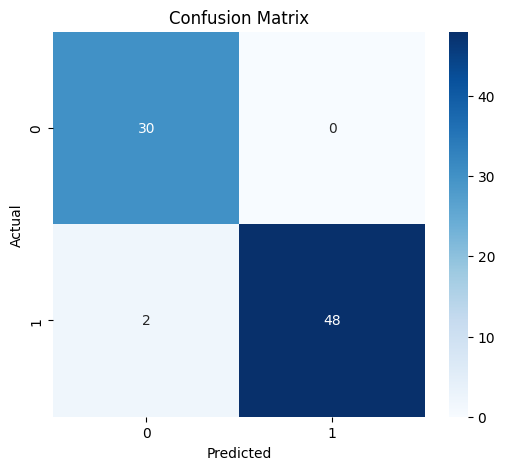

                Feature  Importance
7            hemoglobin    0.351822
9     diabetes_mellitus    0.181959
8          hypertension    0.180827
4      serum_creatinine    0.144859
2  blood_glucose_random    0.035619
5                sodium    0.031804
1        blood_pressure    0.020925
0                   age    0.020126
3            blood_urea    0.016576
6             potassium    0.015481


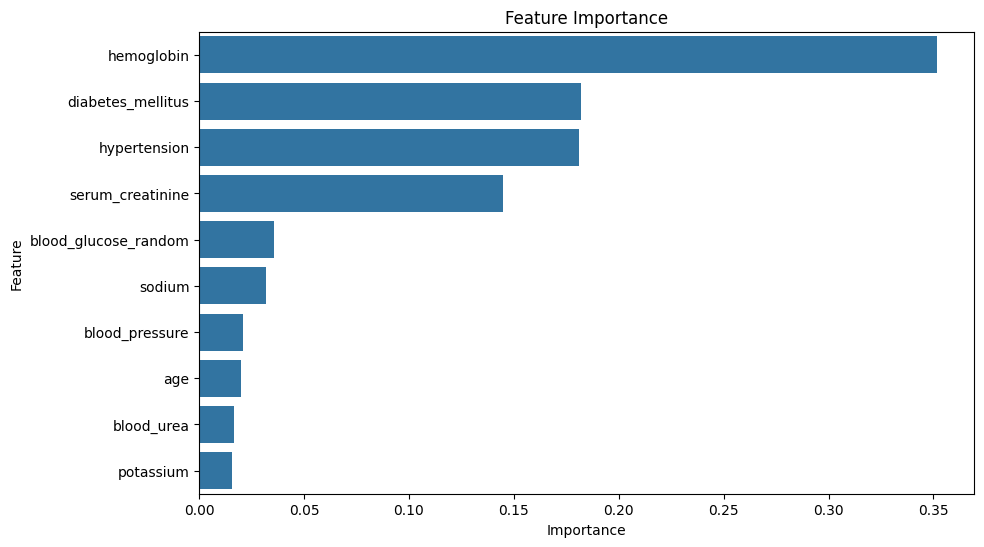

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test_uci, y_pred_risk)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": xgb_risk_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [10]:
# Save trained model
joblib.dump(
    xgb_risk_model,
    "models/ckd_risk_prediction_model.joblib"
)

# Save scaler
joblib.dump(
    scaler_uci,
    "models/uci_scaler.joblib"
)

# Save feature names
joblib.dump(
    selected_features,
    "models/uci_feature_names.joblib"
)

# Save encoders
joblib.dump(
    encoders_uci,
    "models/uci_encoders.joblib"
)

print("Model Saved Successfully")

Model Saved Successfully


In [11]:
# Load NHANES dataset for CKD Stage Prediction

nhanes_data = pd.read_csv(r"C:\Users\DELL\nephrocare\data\processed\nhanes_ckd.csv")

print("="*80)
print("NHANES DATASET")
print("="*80)

print("Shape:", nhanes_data.shape)

print("\nFirst 5 Rows:")
print(nhanes_data.head())

print("\nColumns:")
print(nhanes_data.columns.tolist())

print("\nMissing Values:")
print(nhanes_data.isnull().sum())

NHANES DATASET
Shape: (9693, 26)

First 5 Rows:
   participant_id   age  sex_code  race_ethnicity_code  SDMVSTRA  SDMVPSU  \
0        109266.0  29.0       2.0                  6.0     168.0      2.0   
1        109267.0  21.0       2.0                  2.0     156.0      1.0   
2        109268.0  18.0       2.0                  3.0     155.0      1.0   
3        109271.0  49.0       1.0                  3.0     167.0      1.0   
4        109273.0  36.0       1.0                  3.0     155.0      1.0   

   serum_creatinine_mg_dl  serum_albumin_g_dl  blood_urea_nitrogen_mg_dl  \
0                    0.63                 3.8                        8.0   
1                     NaN                 NaN                        NaN   
2                     NaN                 NaN                        NaN   
3                    0.78                 3.8                        8.0   
4                    0.92                 4.6                       11.0   

   serum_glucose_mg_dl  ...  hem

In [12]:
# Convert eGFR values into CKD stages
# These stages will be used as target labels for the model

def calculate_ckd_stage(egfr):

    if pd.isna(egfr):
        return np.nan

    egfr = float(egfr)

    if egfr >= 90:
        return 1      # Stage 1

    elif egfr >= 60:
        return 2      # Stage 2

    elif egfr >= 45:
        return 3      # Stage 3a

    elif egfr >= 30:
        return 4      # Stage 3b

    elif egfr >= 15:
        return 5      # Stage 4

    else:
        return 6      # Stage 5


df_nhanes = nhanes_data.copy()

# Create a new target column
df_nhanes["ckd_stage"] = df_nhanes["egfr_2021"].apply(
    calculate_ckd_stage
)

print("CKD Stage Labels Created Successfully")

print("\nStage Distribution:")
print(
    df_nhanes["ckd_stage"]
    .value_counts()
    .sort_index()
)

CKD Stage Labels Created Successfully

Stage Distribution:
ckd_stage
1.0    5196
2.0    2392
3.0     438
4.0     147
5.0      54
6.0      30
Name: count, dtype: int64


In [13]:
# Features used for CKD stage prediction

nhanes_features = [

    'age',
    'sex_code',
    'serum_creatinine_mg_dl',
    'serum_albumin_g_dl',
    'blood_urea_nitrogen_mg_dl',
    'serum_glucose_mg_dl',
    'potassium_mmol_l',
    'sodium_mmol_l',
    'hemoglobin_g_dl',
    'mean_systolic_bp',
    'mean_diastolic_bp'

]

# Keep only required features and target

df_nhanes_clean = df_nhanes[
    nhanes_features + ['ckd_stage']
].copy()

# Remove rows where stage is missing

df_nhanes_clean = df_nhanes_clean[
    df_nhanes_clean['ckd_stage'].notna()
]

# Fill missing values using median

for col in nhanes_features:

    df_nhanes_clean[col] = df_nhanes_clean[col].fillna(
        df_nhanes_clean[col].median()
    )

# XGBoost requires classes starting from 0
# Stage 1→0, Stage 2→1, ..., Stage 5→5

df_nhanes_clean['ckd_stage'] = (
    df_nhanes_clean['ckd_stage'] - 1
).astype(int)

print("Dataset Ready for Training")
print("Shape:", df_nhanes_clean.shape)

print("\nStage Distribution:")
print(
    df_nhanes_clean['ckd_stage']
    .value_counts()
    .sort_index()
)

print("\nUnique Classes:")
print(sorted(df_nhanes_clean['ckd_stage'].unique()))

Dataset Ready for Training
Shape: (8257, 12)

Stage Distribution:
ckd_stage
0    5196
1    2392
2     438
3     147
4      54
5      30
Name: count, dtype: int64

Unique Classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [14]:
X_nhanes = df_nhanes_clean[nhanes_features].copy()

# Force labels to start at 0
y_nhanes = (
    df_nhanes_clean['ckd_stage']
    .astype(int)
    - 1
)

print("Unique Classes:")
print(sorted(y_nhanes.unique()))

scaler_nhanes = StandardScaler()

X_nhanes_scaled = scaler_nhanes.fit_transform(
    X_nhanes
)

X_nhanes_scaled = pd.DataFrame(
    X_nhanes_scaled,
    columns=nhanes_features
)

X_train_nhanes, X_test_nhanes, y_train_nhanes, y_test_nhanes = train_test_split(
    X_nhanes_scaled,
    y_nhanes,
    test_size=0.20,
    random_state=42,
    stratify=y_nhanes
)

print("\nTraining Class Distribution:")
print(y_train_nhanes.value_counts().sort_index())

Unique Classes:
[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Training Class Distribution:
ckd_stage
-1    4156
 0    1914
 1     350
 2     118
 3      43
 4      24
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

label_encoder = LabelEncoder()

y_train_nhanes = label_encoder.fit_transform(y_train_nhanes)
y_test_nhanes = label_encoder.transform(y_test_nhanes)

n_classes = len(np.unique(y_train_nhanes))

print(f"Number of CKD Stages: {n_classes}")

xgb_stage_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

print("\nTraining CKD Stage Model...")

xgb_stage_model.fit(
    X_train_nhanes,
    y_train_nhanes
)

print("Model Training Completed Successfully")

print("\nModel Classes:")
print(xgb_stage_model.classes_)

Number of CKD Stages: 6

Training CKD Stage Model...
Model Training Completed Successfully

Model Classes:
[0 1 2 3 4 5]


In [17]:
# Predict CKD stages for test data

y_pred_stage = xgb_stage_model.predict(
    X_test_nhanes
)

# Calculate evaluation metrics

accuracy_stage = accuracy_score(
    y_test_nhanes,
    y_pred_stage
)

precision_stage = precision_score(
    y_test_nhanes,
    y_pred_stage,
    average="weighted",
    zero_division=0
)

recall_stage = recall_score(
    y_test_nhanes,
    y_pred_stage,
    average="weighted",
    zero_division=0
)

f1_stage = f1_score(
    y_test_nhanes,
    y_pred_stage,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("CKD STAGE CLASSIFICATION RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy_stage:.4f}")
print(f"Precision : {precision_stage:.4f}")
print(f"Recall    : {recall_stage:.4f}")
print(f"F1 Score  : {f1_stage:.4f}")

print("\nDetailed Classification Report")
print(
    classification_report(
        y_test_nhanes,
        y_pred_stage,
        zero_division=0
    )
)

# Convert model labels back to medical stage names

stage_mapping = {
    0: "Stage 1",
    1: "Stage 2",
    2: "Stage 3a",
    3: "Stage 3b",
    4: "Stage 4",
    5: "Stage 5"
}

results_df = pd.DataFrame({
    "Actual": y_test_nhanes,
    "Predicted": y_pred_stage
})

results_df["Actual"] = results_df["Actual"].map(stage_mapping)
results_df["Predicted"] = results_df["Predicted"].map(stage_mapping)

print("\nSample Predictions")
print(results_df.head(10))

CKD STAGE CLASSIFICATION RESULTS
Accuracy  : 0.9831
Precision : 0.9830
Recall    : 0.9831
F1 Score  : 0.9828

Detailed Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1040
           1       0.98      0.98      0.98       478
           2       0.93      0.95      0.94        88
           3       0.84      0.90      0.87        29
           4       0.86      0.55      0.67        11
           5       1.00      1.00      1.00         6

    accuracy                           0.98      1652
   macro avg       0.93      0.90      0.91      1652
weighted avg       0.98      0.98      0.98      1652


Sample Predictions
    Actual Predicted
0  Stage 1   Stage 1
1  Stage 1   Stage 1
2  Stage 1   Stage 1
3  Stage 1   Stage 1
4  Stage 2   Stage 2
5  Stage 1   Stage 1
6  Stage 1   Stage 1
7  Stage 1   Stage 1
8  Stage 1   Stage 1
9  Stage 1   Stage 1


In [18]:
import joblib

features = joblib.load("models/uci_feature_names.joblib")
print(features)

['age', 'blood_pressure', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'hemoglobin', 'hypertension', 'diabetes_mellitus']


Generating SHAP values...


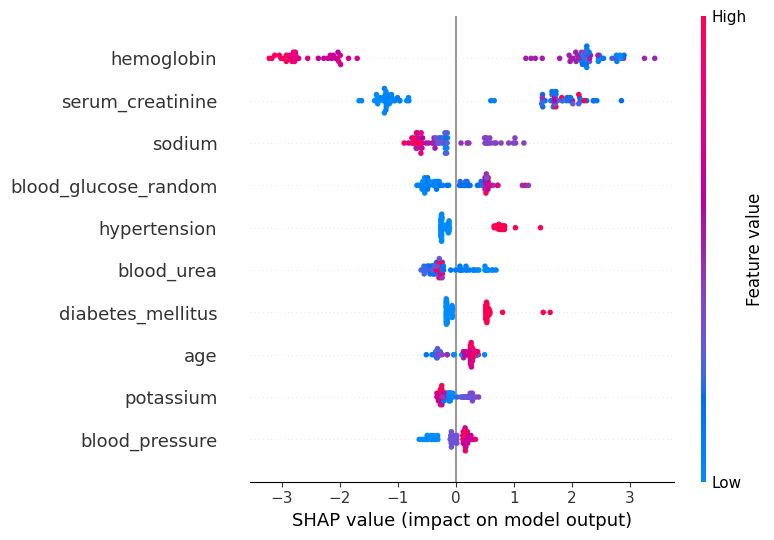

In [19]:
import shap
import matplotlib.pyplot as plt

print("Generating SHAP values...")

explainer = shap.TreeExplainer(xgb_risk_model)

shap_values = explainer.shap_values(X_test_uci)

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test_uci,
    feature_names=X_test_uci.columns,
    show=False
)
plt.tight_layout()
plt.savefig("models/shap_summary.png", dpi=300)
plt.show()

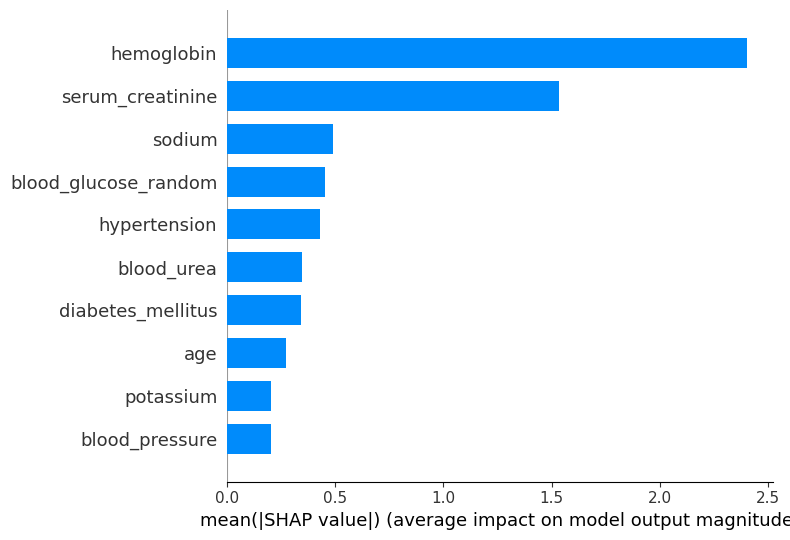

In [20]:
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_test_uci,
    feature_names=X_test_uci.columns,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("models/shap_feature_importance.png", dpi=300)
plt.show()

<Figure size 2000x400 with 0 Axes>

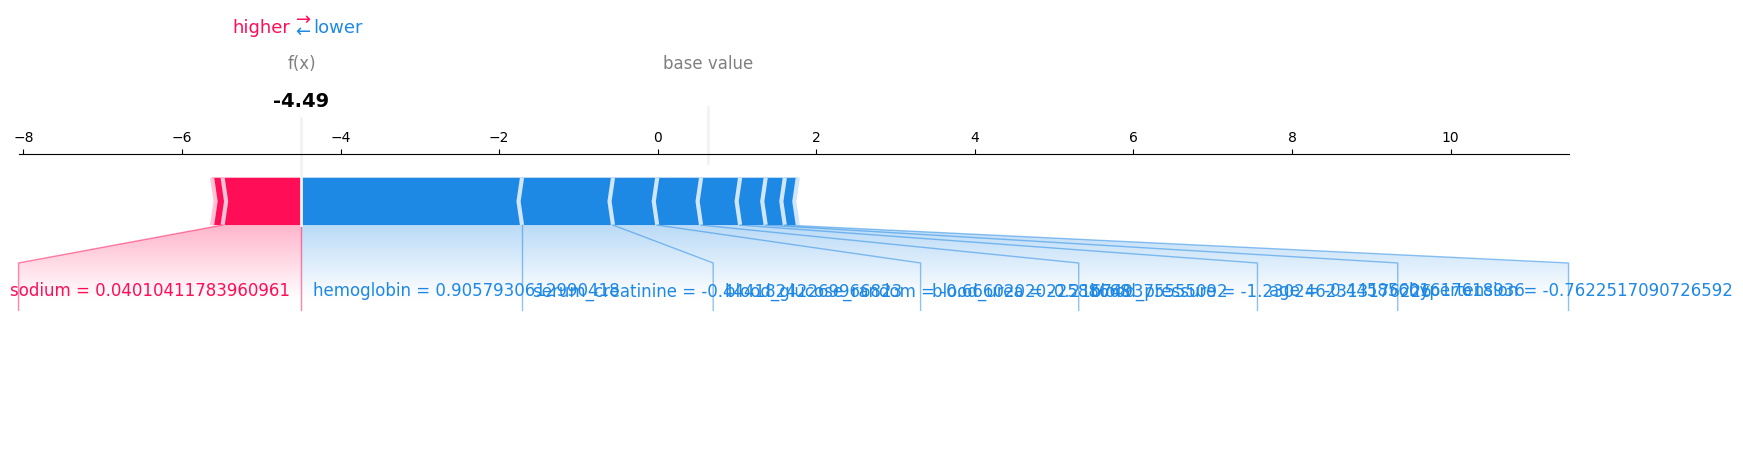

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure(figsize=(20, 4))

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample,
    matplotlib=True,
    figsize=(20,4)
)

plt.savefig("models/sample_explanation.png", dpi=300)
plt.show()

<Figure size 1000x800 with 0 Axes>

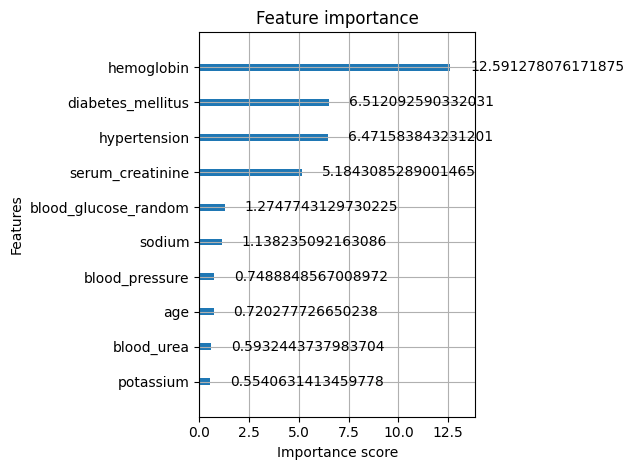

In [25]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    xgb_risk_model,
    importance_type="gain",
    max_num_features=15
)

plt.tight_layout()
plt.savefig("models/xgb_feature_importance.png")
plt.show()

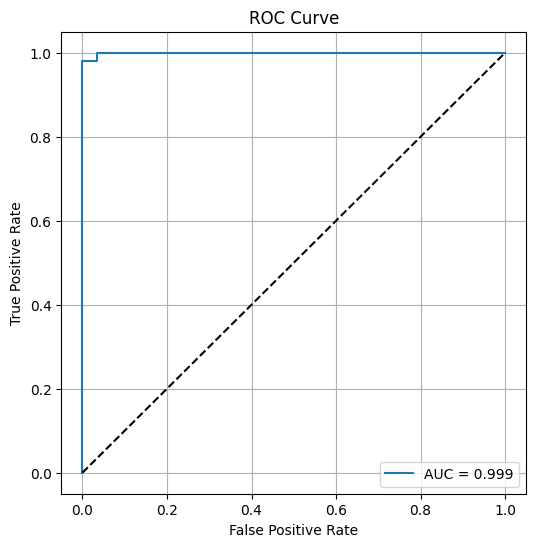

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = xgb_risk_model.predict_proba(X_test_uci)[:,1]

fpr, tpr, _ = roc_curve(y_test_uci, y_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("models/roc_curve.png")
plt.show()

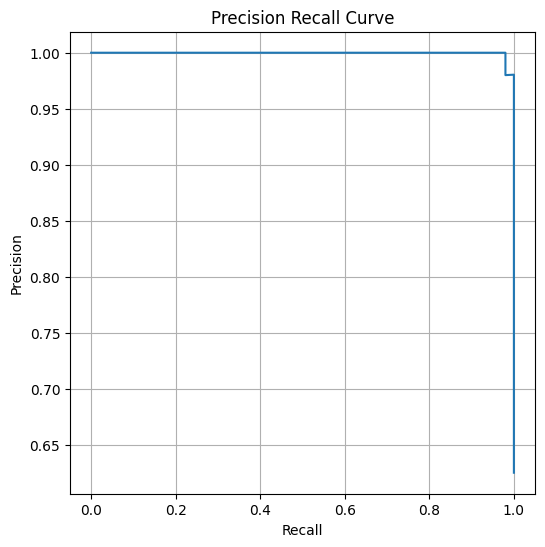

In [27]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test_uci,
    y_prob
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.grid(True)

plt.savefig("models/pr_curve.png")
plt.show()

In [29]:
import joblib

joblib.dump(
    explainer,
    "models/shap_explainer.joblib"
)

['models/shap_explainer.joblib']